In [4]:
import math

import numpy as np
import pandas as pd
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

import spacy
import torch
import torch.nn as nn
import torch.utils as utils
import torch.optim as optim
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import tokenizers
import matplotlib.pyplot as plt

from tqdm import tqdm
import glob

from PIL import Image
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

In [5]:
def check_folder(data_path):
    """
    Функция возвращает данные о содержимом папки
    :param data_path: folder path
    """
    folder = Path(data_path)
    
    total_files = 0
    total_folders = 0
    total_size = 0
    extensions = []
    
    for item in folder.rglob('*'):  # рекурсивно пройдем по всем вложенным файлам и папкам
        if item.is_file():
            total_files += 1
            total_size += item.stat().st_size
            ext = item.suffix.lower() if item.suffix else 'без расширения'
            extensions.append(ext)
        elif item.is_dir():
            total_folders += 1
    
    ext_counts = Counter(extensions)
    
    folder_stats = (total_files, total_folders, total_size)
    
    print(f"Статистика папки: {data_path}")
    print(f"Всего файлов: {total_files}")
    print(f"Всего папок (включая вложенные): {total_folders}")
    print(f"Общий размер файлов: {total_size / (1024**2):.2f} МБ")
    print("\nРаспределение по расширениям файлов:")
    for ext, count in ext_counts.most_common():
        print(f"  {ext}: {count}")
    return folder_stats

In [6]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'Flickr')
image_location = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data/Flickr', 'flickr30k_img')
models_path = os.path.join(data_path, 'models')
if not os.path.exists(image_location):
    os.makedirs(image_location)

In [7]:
from kaggle.api.kaggle_api_extended import KaggleApi

folder_stats = check_folder(image_location)
if folder_stats[2] == 0:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files("hsankesara/flickr-image-dataset", path=image_location, unzip=True)
    print("\nЗагрузка завершена")
else:  print("\nПапка не пустая")

Статистика папки: /Users/aleksandrkoval/PycharmProjects/ML/src/data/Flickr/flickr30k_img
Всего файлов: 31783
Всего папок (включая вложенные): 0
Общий размер файлов: 4211.77 МБ

Распределение по расширениям файлов:
  .jpg: 31783

Папка не пустая


In [8]:
# Fixing the results.csv file

img_dir = image_location
anno_dir = os.path.join(data_path, 'results.csv')
with open(anno_dir, 'r') as results, open(os.path.join(data_path, 'new_results.csv'), 'w') as new_results:
    for line in results:
        if len(line.split('|')) != 3:
            line = line.replace("   ", "|  ")
        new_results.write(line)
        
df = pd.read_csv(os.path.join(data_path, 'new_results.csv'), sep='|')
df.head()

,image_name,comment_number,comment
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [9]:
metadata = pd.read_csv(os.path.join(data_path, 'results.csv'), sep='|')
metadata.columns = ['image_name', 'comment_number', 'comment_text']
metadata.head()

,image_name,comment_number,comment_text
0,1000092795.jpg,0,Two young guys with shaggy hair look at their...
1,1000092795.jpg,1,"Two young , White males are outside near many..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .


In [10]:
spacy_end = spacy.load("en_core_web_sm") #загрузка модели spaCy для английского языка, которая включает токенизатор и другие NLP-компоненты.

class Vocabulary:
    def __init__(self, freq_threshold):
        """Класс, который управляет словарём слов для задач обработки естественного языка (NLP), используя токенизацию spaCy.
        Инициализирует два словаря:
	    `itos` — словарь “индекс в слово” для преобразования индексов обратно в слова, с начальными специальными токенами `<PAD>`, `<SOS>`, `<EOS>`, `<UNK>`.
	    `stoi` — обратный словарь “слово в индекс”.
	    :param freq_threshold: — порог частоты, при достижении которого слово добавляется в словарь"""
        self.itos = {0:"<PAD>", 1:"<SOS>", 2:"<EOS>", 3:"<UNK>"} 
        self.stoi = {"<PAD>":0, "<SOS>":1, "<EOS>":2, "<UNK>":3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod 
    def tokenizer_eng(text):
        """ Статический метод класса, который разбивает входной текст на токены с помощью spaCy токенизатора и приводит их к нижнему регистру."""
        return [token.text.lower() for token in spacy_end.tokenizer(text)]

    def numericalize(self, text):
        """ Преобразует каждый токен в соответствующий индекс из словаря `stoi`. Если слово не найдено, используется индекс `<UNK>`
        :param text: текст для обработки"""
        tokenized_text = self.tokenizer_eng(text)

        return [
            self.stoi[token] if token in self.stoi else self.stoi["<UNK>"]
            for token in tokenized_text
        ]

    def build_vocabulary(self, sentence_list):
        """Построение словаря из списка предложений
        :param sentence_list: список предложений для словаря"""
        frequencies = {}
        idx = 4 

        # изучение всех слов и их частоты появления
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                if word not in frequencies:
                    frequencies[word] = 1
                else:
                    frequencies[word] += 1

                # Добавление слов в словарь, если слово встречается с нужной частотой
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

In [11]:
# Инициализируем словарь
vocab = Vocabulary(5)
vocab.itos[0]

'<PAD>'

In [12]:
# Build vocabulary then check if new words were added
vocab.build_vocabulary(df[' comment'].tolist())
vocab.itos[13]

'standing'

In [13]:
class FlickrDataset(utils.data.Dataset):
        """
    Класс для создания пользовательского датасета Flickr с изображениями и подписями для обучения моделей.

    Args:
        root_dir (str): Путь к каталогу с изображениями.
        img_caption_df (pd.DataFrame): DataFrame с названиями изображений и подписями.
        transform (callable, optional): Преобразования для изображений (аугментация, нормализация). По умолчанию None.
        mode (str, optional): Режим работы датасета: 'train', 'val' или 'test'. По умолчанию 'train'.
        vocab (object, optional): Объект словаря для числового кодирования подписей. По умолчанию None.

    Attributes:
        df (pd.DataFrame): Выбранная часть данных в соответствии с режимом.
        transform (callable): Применяемые преобразования к изображениям.
        vocab (object): Словарь для преобразования текста в числа.
        random_seed (int): Фиксированный сид для воспроизводимости разбиения данных.
    """
     # Конструктор класса
    def __init__(self, root_dir, img_caption_df, transform=None, mode='train', vocab=None):
        self.root_dir = root_dir  # Путь к директории с изображениями
        self.df = img_caption_df  # DataFrame с названиями изображений и подписями
        self.mode = mode  # Режим работы: train, val или test
        self.vocab = vocab  # Словарь для преобразования текста в числа
        self.random_seed = 42  # Фиксированное значение для воспроизводимости разбивки данных

        # Разбиваем данные на тренировочные и временные (для валидации и теста) 80%/20%
        train_df, temp_df = train_test_split(self.df, test_size=0.2, random_state=self.random_seed)

        # В зависимости от режима оставляем соответствующий поднабор данных
        if self.mode == 'train':
            self.df = train_df  # Для тренировки
        elif self.mode == 'val':
            # Делим временные данные на валидационные и тестовые поровну
            val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=self.random_seed)
            self.df = val_df  # Для валидации
        else:
            # Остаток идет на тестирование
            val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=self.random_seed)
            self.df = test_df  # Для теста
            
        # Устанавливаем трансформации. Если не заданы, используем стандартные преобразования:
        # изменение размера до 299x299, преобразование в тензор и нормализация каналов
        if transform is None:
            self.transform = transforms.Compose([
                transforms.Resize((299, 299)),  # Изменяем размер изображения
                transforms.ToTensor(),  # Преобразуем в тензор PyTorch
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # Нормализуем каналы RGB
            ])
        else:
            self.transform = transform  # Используем переданные преобразования

    # Возвращает количество элементов в датасете
    def __len__(self):
        """
        Возвращает количество образцов в датасете.
        Returns:
            int: Размер датасета.
        """
        return len(self.df)

    # Возвращает элемент датасета по индексу
    def __getitem__(self, index):
        """
        Получение одного образца из датасета по индексу.
        Args:
            index (int): Индекс записи в датафрейме.
        Returns:
            tuple: Кортеж (изображение в виде тензора, числовой массив подписи, имя файла).
        """
        row = self.df.iloc[index]  # Получаем строку с данными
        caption = row[' comment']  # Получаем подпись к изображению
        img_id = row['image_name']  # Получаем имя файла изображения

        # Загружаем изображение и конвертируем в RGB
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")

        # Применяем преобразования, если они заданы
        if self.transform is not None:
            img = self.transform(img)

        # Преобразуем подпись в числовой формат, добавляя специальные токены начала и конца
        numericalized_caption = [self.vocab.stoi["<SOS>"]]  # Токен начала последовательности
        numericalized_caption += self.vocab.numericalize(caption)  # Числовое представление подписи
        numericalized_caption.append(self.vocab.stoi["<EOS>"])  # Токен конца последовательности
        # Формат: <SOS> Подпись <EOS>
        
        # Возвращаем изображение, числовую подпись и имя файла
        return img, torch.tensor(numericalized_caption), img_id

In [14]:
class Collate():
    """
    Класс для объединения данных одного батча в DataLoader.
    Args:
        pad_idx (int): Индекс для заполнения (padding) последовательностей различной длины.
    Методы:
        __call__(batch):
            Принимает батч из датасета (список кортежей (изображение, подпись, id))
            и возвращает:
                - тензор изображений с добавленной размерностью батча,
                - выровненные (padding) подписи в виде тензора,
                - список id изображений.
    """
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx
        """
        Обработка батча данных: объединение изображений в один тензор,
        паддинг последовательностей подписей и извлечение id изображений.
        Args:
            batch (list): Список элементов датасета вида (изображение, подпись, id).
        Returns:
            tuple: (imgs, targets, img_ids)
                imgs (torch.Tensor): Тензор размерности (batch_size, C, H, W) с батчем изображений.
                targets (torch.Tensor): Выровненные подписи с паддингом.
                img_ids (list): Список имен файлов изображений.
        """
    def __call__(self, batch):
        # imgs = [item[0].unsqueeze(0) for item in batch]
        # imgs = torch.cat(imgs, dim=0)
        # Собираем изображения из батча и объединяем в тензор с размерностью батча
        imgs = torch.stack([item[0] for item in batch], dim=0)
        # Извлекаем подписи из батча
        targets = [item[1] for item in batch]
        # Применяем паддинг к подпиясям, чтобы иметь одинаковую длину во всех элементах
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)
        
        # Извлекаем списком id изображений
        img_ids = [item[2] for item in batch]
        
        return imgs, targets, img_ids

In [15]:
def get_loader(
    root_folder,
    df,
    transform,
    vocab,
    batch_size=32,
    num_workers=0,
    shuffle=True,
    pin_memory=True,
):
    """
    Функция для создания загрузчиков данных (DataLoader) для обучающего, валидационного и тестового наборов.
    Args:
        root_folder (str): Путь к папке с изображениями.
        df (pd.DataFrame): DataFrame с названиями изображений и подписями.
        transform (callable): Преобразования, применяемые к изображениям в обучающей выборке.
        vocab (object): Словарь для числового кодирования подписей.
        batch_size (int, optional): Размер батча для обучающего и валидационного DataLoader. По умолчанию 32.
        num_workers (int, optional): Число подпроцессов для загрузки данных. По умолчанию 0.
        shuffle (bool, optional): Флаг перемешивания данных. По умолчанию True.
        pin_memory (bool, optional): Флаг закрепления памяти для ускорения передачи данных CUDA. По умолчанию True.
    Returns:
        tuple: Кортеж из четырёх элементов:
            - train_loader (DataLoader): загрузчик обучающих данных.
            - val_loader (DataLoader): загрузчик валидационных данных.
            - test_loader (DataLoader): загрузчик тестовых данных.
            - train_dataset (Dataset): объект обучающего датасета.
    """
    # Создаём обучающий датасет
    train_dataset = FlickrDataset(root_folder, df, transform=transform, vocab=vocab)
    # Создаём валидационный датасет, применяя transform для теста/валидации
    val_dataset = FlickrDataset(root_folder, df, transform=test_transform, mode='val', vocab=vocab)
    # Создаём тестовый датасет
    test_dataset = FlickrDataset(root_folder, df, transform=test_transform, mode='test', vocab=vocab)
    # Индекс паддинга в словаре для обработки подписей разной длины
    pad_idx = vocab.stoi["<PAD>"]

    # Загружаем данные для обучения с батчами, перемешиванием и использованием класса Collate для паддинга
    train_loader = utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=Collate(pad_idx=pad_idx),
    )

    # Загружаем данные для валидации с аналогичными параметрами
    val_loader = utils.data.DataLoader(
        dataset=val_dataset,
        batch_size=batch_size,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=Collate(pad_idx=pad_idx),
    )
    
    # Загружаем данные для теста с батчем размера 1 и теми же параметрами
    test_loader = utils.data.DataLoader(
        dataset=test_dataset,
        batch_size=1,
        num_workers=num_workers,
        shuffle=shuffle,
        pin_memory=pin_memory,
        collate_fn=Collate(pad_idx=pad_idx),
    )
    
    # Возвращаем загрузчики и объект обучающего датасета
    return train_loader, val_loader, test_loader, train_dataset

In [16]:
class EncoderCNN(nn.Module):
    """
    Класс энкодера изображений на основе сверточной нейронной сети (CNN) Inception v3.
    Args:
        embed_size (int): Размерность выходного вектора признаков (встраивания).
        train_CNN (bool, optional): Флаг обучения весов CNN. Если False, сверточная часть заморожена. По умолчанию False.
    Атрибуты:
        cnn (nn.Sequential): Сверточная часть модели без последнего fully connected слоя.
        adaptive_pool (nn.AdaptiveAvgPool2d): Адаптивный средний пул для выравнивания пространственного размера признаков.
        linear (nn.Linear): Полносвязный слой для проекции признаков в пространство размером embed_size.
    Особенности:
        При инициализации загружает предобученную сеть Inception v3.
        Позволяет заморозить свёрточные веса для фиксации извлечённых признаков.
    """    
    def __init__(self, embed_size, train_CNN=False):
        super(EncoderCNN, self).__init__()
        self.train_CNN = train_CNN
        inception = models.inception_v3(weights='DEFAULT', aux_logits=True)
        # Создаем последовательность из всех блоков Inception, кроме последнего fully connected слоя
        modules = list(inception.children())[:-1]
        # В явном виде перечисляем основные блоки свёрточной сети Inception v3
        # self.cnn = nn.Sequential(*modules)
        self.cnn = nn.Sequential(
            inception.Conv2d_1a_3x3,
            inception.Conv2d_2a_3x3,
            inception.Conv2d_2b_3x3,
            nn.MaxPool2d(3, stride=2),
            inception.Conv2d_3b_1x1,
            inception.Conv2d_4a_3x3,
            nn.MaxPool2d(3, stride=2),
            inception.Mixed_5b,
            inception.Mixed_5c,
            inception.Mixed_5d,
            inception.Mixed_6a,
            inception.Mixed_6b,
            inception.Mixed_6c,
            inception.Mixed_6d,
            inception.Mixed_6e,
            inception.Mixed_7a,
            inception.Mixed_7b,
            inception.Mixed_7c,
        )

        # Адаптивный пул для одинакового размера выходных признаков (8x8)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))
        # Линейный слой для преобразования признаков в нужную размерность embed_size
        self.linear = nn.Linear(2048, embed_size)

        # Замораживаем веса свёрточной сети, если train_CNN=False, кроме fc-слоя
        for name, param in self.cnn.named_parameters():
            if "fc.weight" in name or "fc.bias" in name:
                param.requires_grad = True
            else:
                param.requires_grad = self.train_CNN

    def forward(self, images):
        """
        Прямой проход по модели.
        Args:
            images (torch.Tensor): Батч изображений размером (B, C, H, W).
        Returns:
            torch.Tensor: Векторы признаков размером (B, 64, embed_size), где 64 = 8*8 пространственных позиций.
        """
        # Извлекаем признаки из свёрточной части (B, 2048, H, W)
        features = self.cnn(images)
        # Применяем адаптивный пул, чтобы получить фиксированный размер (B, 2048, 8, 8)
        features = self.adaptive_pool(features)
        # Меняем порядок осей для удобства (B, 8, 8, 2048)
        features = features.permute(0, 2, 3, 1)
        # Выравниваем пространственные оси, чтобы получить последовательность признаков (B, 64, 2048)
        features = features.view(features.size(0), -1, 2048)
        # Преобразуем признаки в конечное пространство размерности embed_size (B, 64, embed_size)
        features = self.linear(features)
        return features

In [17]:
class Attention(nn.Module):
    """
    Механизм внимания (Attention) для объединения выходных признаков энкодера и скрытого состояния декодера.

    Args:
        encoder_dim (int): Размерность выходных признаков энкодера.
        decoder_dim (int): Размерность скрытого состояния декодера.
        attention_dim (int): Размерность внутреннего пространства для вычисления весов внимания.

    Атрибуты:
        encoder_attn (nn.Linear): Линейный слой для проекции признаков энкодера в пространство внимания.
        decoder_attn (nn.Linear): Линейный слой для проекции скрытого состояния декодера в пространство внимания.
        full_attn (nn.Linear): Финальный линейный слой для вычисления энергии внимания (скалярного значения).
        relu (nn.ReLU): Функция активации ReLU.
        softmax (nn.Softmax): Функция softmax для нормализации весов внимания по пространственному измерению.
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_attn = nn.Linear(encoder_dim, attention_dim)
        self.decoder_attn = nn.Linear(decoder_dim, attention_dim)
        self.full_attn = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, hidden_state):
        """
        Прямой проход механизма внимания.

        Args:
            encoder_out (torch.Tensor): Выходы энкодера, тензор размером (batch_size, num_pixels, encoder_dim).
            hidden_state (torch.Tensor): Текущее скрытое состояние декодера размером (batch_size, decoder_dim).

        Returns:
            tuple: (context, alpha)
                context (torch.Tensor): Взвешенное по вниманию контекстное представление (batch_size, encoder_dim).
                alpha (torch.Tensor): Распределение внимания (batch_size, num_pixels).
        """
        # Проецируем признаки энкодера в пространство внимания
        e_attn = self.encoder_attn(encoder_out)  # (B, num_pixels, attention_dim)
        # Проецируем скрытое состояние декодера и добавляем размер измерения для сложения
        d_attn = self.decoder_attn(hidden_state).unsqueeze(1)  # (B, 1, attention_dim)
        
        # d_attn = d_attn.permute(1, 0, 2)
        # print(d_attn.shape)
        
        # Суммируем проекции, применяем ReLU и вычисляем энергию внимания через линейный слой
        attn = self.full_attn(self.relu(e_attn + d_attn)).squeeze(2)  # (B, num_pixels)
        # Применяем softmax для получения распределения весов внимания
        alpha = self.softmax(attn)  # (B, num_pixels)
        # Вычисляем контекст как взвешенную сумму признаков энкодера с учётом внимания
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (B, encoder_dim)
        return context, alpha

In [18]:
class DecoderRNN(nn.Module):
    """
    Рекуррентный декодер (LSTM) с механизмом внимания для генерации последовательностей слов (подписей).
    Args:
        embed_size (int): Размерность эмбеддингов слов.
        hidden_size (int): Размерность скрытого состояния LSTM.
        vocab_size (int): Размер словаря (число уникальных токенов).
        num_layers (int): Количество слоев LSTM.
    Атрибуты:
        embed (nn.Embedding): Слой для преобразования индексов слов в эмбеддинги.
        attn (Attention): Модуль механизма внимания.
        lstm (nn.LSTM): Рекуррентный слой LSTM, принимающий на вход эмбеддинг и контекст.
        linear (nn.Linear): Полносвязный слой для предсказания вероятности каждого слова словаря.
        dropout (nn.Dropout): Слой dropout для регуляризации.
    Особенности:
        Использует teacher forcing с вероятностью `teacher_forcing_ratio` для обучения.
    """
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        encoder_dim = 256
        attn_dim = 256
        self.num_layers = num_layers
        self.embed = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attn = Attention(encoder_dim, hidden_size, attn_dim)
        self.lstm = nn.LSTM(embed_size+encoder_dim, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions, teacher_forcing_ratio=0.5):
        """
        Прямой проход по декодеру с механизмом teacher forcing.
        Args:
            features (torch.Tensor): Признаки из энкодера формы (batch_size, num_pixels, encoder_dim).
            captions (torch.Tensor): Входные подписи (токены) формы (batch_size, max_seq_len).
            teacher_forcing_ratio (float): Вероятность использования истинного токена как следующего входа во время обучения.
        Returns:
            torch.Tensor: Выходные логиты для каждого слова в словаре, размерность (batch_size, max_seq_len, vocab_size).
        """
        # Features shape: (Batch, 8x8, 256)
        # Captions shape: (Batch, Caption's length)
        batch_size = features.size(0)
        num_pixels = features.size(1)
        vocab_size = self.linear.out_features
        
        # Получаем эмбеддинги для всех слов в подписи
        embeddings = self.embed(captions) # (B, max_len, embed_size)
        
        # Инициализируем скрытые состояния LSTM нулями
        h, c = (torch.zeros(self.num_layers, batch_size, self.lstm.hidden_size, device=features.device),
                torch.zeros(self.num_layers, batch_size, self.lstm.hidden_size, device=features.device))
        
        # Тензор для хранения выходов модели по всем временным шагам
        outputs = torch.zeros(batch_size, captions.size(1), vocab_size,device=features.device)

        # Цикл по каждому слову в подписи
        for t in range(captions.size(1)):
            if t == 0 or torch.rand(1, device=features.device) < teacher_forcing_ratio:
                # Используем истинный токен на вход (teacher forcing)
                word_embed = embeddings[:, t, :]
            else:
                # Используем предсказанный токен предыдущего шага
                prev_word = outputs[:, t - 1, :].argmax(dim=1)
                word_embed = self.embed(prev_word)

            # Берем скрытое состояние последнего слоя LSTM
            h_top = h[-1]
            # Вычисляем контекстный вектор с помощью механизма внимания
            context, alpha = self.attn(features, h_top)

            # Объединяем эмбеддинг слова и контекстный вектор
            lstm_input = torch.cat([word_embed, context], dim=1).unsqueeze(1)
            # Пропускаем через LSTM и обновляем скрытые состояния
            lstm_out, (h, c) = self.lstm(lstm_input, (h, c))

            # Применяем dropout, а затем полносвязный слой для предсказания слов
            out = self.linear(self.dropout(lstm_out)).squeeze(1)

            # Сохраняем предсказания для текущего временного шага
            outputs[:, t, :] = out

        return outputs

In [19]:
class CNNtoRNN(nn.Module):
    """
    Класс объединяющий сверточный энкодер и рекуррентный декодер для генерации подписей к изображениям.

    Args:
        embed_size (int): Размерность эмбеддингов (встраиваний) признаков.
        hidden_size (int): Размерность скрытого состояния LSTM в декодере.
        vocab_size (int): Размер словаря (число уникальных токенов).
        num_layers (int): Количество слоев в LSTM декодера.

    Атрибуты:
        encoderCNN (EncoderCNN): Энкодер, извлекающий признаки из изображений.
        decoderRNN (DecoderRNN): Декодер, генерирующий подписи, используя признаки и скрытое состояние.

    Методы:
        forward(images, captions):
            Прямой проход через энкодер и декодер, возвращает предсказанные вероятности слов.
        caption_image_beam_search(image, vocabulary, max_length=50, beam_size=4, start_token="<SOS>", end_token="<EOS>"):
            Генерация подписи с использованием поиска луча (beam search).
        caption_image(image, vocabulary, max_length=50, start_token="<SOS>", end_token="<EOS>"):
            Генерация подписи жадным методом (greedy decoding).
    """
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(CNNtoRNN, self).__init__()
        # Инициализация энкодера CNN с размерностью встраивания embed_size
        self.encoderCNN = EncoderCNN(embed_size)
        # Инициализация декодера RNN с заданными параметрами
        self.decoderRNN = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers)

    def forward(self, images, captions):
        """
        Прямой проход модели: извлечение признаков и генерация подписей.

        Args:
            images (torch.Tensor): Входные изображения (B, C, H, W).
            captions (torch.Tensor): Токенизированные подписи (B, max_len).

        Returns:
            torch.Tensor: Предсказанные логиты для каждого слова (B, max_len, vocab_size).
        """
        # Проход изображений через энкодер для получения признаков
        features = self.encoderCNN(images)
        # Передача признаков и подписей в декодер для генерации выходных данных
        outputs = self.decoderRNN(features, captions)
        return outputs

    def caption_image_beam_search(self, image, vocabulary, max_length=50, beam_size=4, start_token="<SOS>", end_token="<EOS>"):
        """
        Генерация подписи к изображению с помощью поиска луча (beam search).

        Args:
            image (torch.Tensor): Одно изображение (C, H, W).
            vocabulary (object): Объект словаря с методами stoi и itos для преобразования токенов.
            max_length (int, optional): Максимальная длина генерируемой подписи. По умолчанию 50.
            beam_size (int, optional): Размер луча для поиска. По умолчанию 4.
            start_token (str, optional): Токен начала последовательности. По умолчанию "<SOS>".
            end_token (str, optional): Токен конца последовательности. По умолчанию "<EOS>".

        Returns:
            list: Сгенерированная подпись в виде списка слов.
        """
        with torch.no_grad():
            # Добавляем размер батча к изображению (1, C, H, W) и пропускаем через энкодер
            features = self.encoderCNN(image.unsqueeze(0))
    
            batch_size = features.size(0)
            device = features.device
    
            # Инициализируем скрытые состояния LSTM нулями (h и c)
            h, c = (torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=device),
                    torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=device))
    
            # Получаем индексы специальных токенов начала и конца предложения
            start_id = vocabulary.stoi[start_token]
            end_id = vocabulary.stoi[end_token]
    
            # Инициализация списка лучей: каждая запись - (текущая последовательность слов, логарифмическая вероятность, h, c)
            beams = [([start_id], 0.0, h, c)]
    
            # Основной цикл по максимальной длине подписи
            for _ in range(max_length):
                candidates = []
                # Проходим по всем текущим лучам
                for seq, score, h, c in beams:
                    # Берём последний токен из последовательности
                    word = torch.tensor([seq[-1]], device=device)
    
                    # Если последовательность уже закончена токеном конца <EOS>, добавляем без изменений
                    if seq[-1] == end_id:
                        candidates.append((seq, score, h, c))
                        continue
    
                    # Преобразуем токен в эмбеддинг
                    word_embed = self.decoderRNN.embed(word)
                    # Берём последнее скрытое состояние LSTM
                    h_top = h[-1]
                    # Вычисляем контекст с помощью механизма внимания
                    context, alpha = self.decoderRNN.attn(features, h_top)
    
                    # Формируем вход для LSTM (эмбеддинг + контекст) и запускаем LSTM один шаг
                    lstm_input = torch.cat([word_embed, context], dim=1).unsqueeze(1)
                    lstm_out, (h_new, c_new) = self.decoderRNN.lstm(lstm_input, (h, c))
    
                    # Получаем логиты слов через полносвязный слой
                    out = self.decoderRNN.linear(lstm_out.squeeze(1))
                    # Применяем log-softmax для получения логарифмов вероятностей
                    log_probs = torch.log_softmax(out, dim=1)
    
                    # Берём top-k наиболее вероятных токенов для расширения текущего луча
                    topk_log_probs, topk_ids = log_probs.topk(beam_size, dim=1)
    
                    # Для каждого из лучших токенов создаём новые кандидаты лучей
                    for k in range(beam_size):
                        # Новая последовательность с добавленным токеном
                        new_seq = seq + [topk_ids[0, k].item()]
                        # Обновлённый суммарный логарифм вероятности
                        new_score = score + topk_log_probs[0, k].item()
                        # Добавляем кандидата с новым состоянием
                        candidates.append((new_seq, new_score, h_new, c_new))
    
                # Отбираем beam_size лучших кандидатов по суммарной вероятности
                beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_size]
    
                # Если все последовательности закончилось <EOS>, прерываем цикл ранее
                if all(seq[-1] == end_id for seq, _, _, _ in beams):
                    break
    
        # Выбираем лучшую последовательность
        best_seq = beams[0][0]
    
        # Преобразуем индексы токенов в слова, исключая специальные токены
        return [vocabulary.itos[idx] for idx in best_seq if idx not in [start_id, end_id]]

    def caption_image(self, image, vocabulary, max_length=50, start_token="<SOS>", end_token="<EOS>"):
        """
        Генерация подписи к изображению жадным методом (greedy decoding).

        Args:
            image (torch.Tensor): Одно изображение (C, H, W).
            vocabulary (object): Словарь с методами stoi и itos.
            max_length (int, optional): Максимальная длина подписи. По умолчанию 50.
            start_token (str, optional): Токен начала последовательности. По умолчанию "<SOS>".
            end_token (str, optional): Токен конца последовательности. По умолчанию "<EOS>".

        Returns:
            list: Сгенерированная подпись в виде списка слов.
        """
        result_caption = []  # Список для хранения предсказанных индексов слов
    
        with torch.no_grad():
            # Добавляем размерность батча к изображению и пропускаем через энкодер
            features = self.encoderCNN(image.unsqueeze(0))
    
            batch_size = features.size(0)
            # Инициализация скрытых состояний LSTM нулями
            h, c = (torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=features.device),
                    torch.zeros(self.decoderRNN.num_layers, batch_size, self.decoderRNN.lstm.hidden_size, device=features.device))
    
            # Начинаем с токена начала последовательности <SOS>
            word = torch.tensor([vocabulary.stoi[start_token]], device=features.device)
    
            # Генерируем подпись поэтапно, пока не достигнем максимальной длины
            for _ in range(max_length):
                # Получаем эмбеддинг текущего слова
                word_embed = self.decoderRNN.embed(word)  # (1, embed_size)
    
                # Берём последнее скрытое состояние из LSTM для внимания
                h_top = h[-1]
                # Вычисляем контекст с помощью механизма внимания
                context, alpha = self.decoderRNN.attn(features, h_top)
    
                # Объединяем эмбеддинг слова и контекстный вектор, добавляем размерность для LSTM
                lstm_input = torch.cat([word_embed, context], dim=1).unsqueeze(1)
                # Один шаг LSTM, обновляем скрытые состояния
                lstm_out, (h, c) = self.decoderRNN.lstm(lstm_input, (h, c))
    
                # Полносвязный слой для получения логитов класса словаря
                out = self.decoderRNN.linear(lstm_out.squeeze(1))  # (1, vocab_size)
                # Определяем слово с максимальной вероятностью
                predicted = out.argmax(1)
    
                # Сохраняем индекс предсказанного слова
                result_caption.append(predicted.item())
                # Используем предсказанное слово для следующего шага
                word = predicted
    
                # Если встретили токен конца <EOS>, прерываем генерацию
                if vocabulary.itos[predicted.item()] == end_token:
                    break
    
        # Преобразуем индексы в слова и возвращаем готовую подпись
        return [vocabulary.itos[idx] for idx in result_caption]

In [20]:
def test(model, criterion, loader, device, epoch):
    """
    Функция тестирования модели на валидационном наборе данных.

    Args:
        model (nn.Module): Модель для тестирования.
        criterion (torch.nn.Module): Функция потерь для вычисления ошибки.
        loader (DataLoader): Загрузчик валидационных данных.
        device (torch.device): Устройство (CPU или GPU) для вычислений.
        epoch (int): Номер текущей эпохи обучения, для контроля вывода примеров.

    Функционал:
        - Переводит модель в режим оценки (eval).
        - Вычисляет суммарный лосс по всему валидационному набору.
        - По завершении выводит средний лосс.
        - Каждые 5 эпох (а также на первой) визуализирует пример изображения с подписью, сгенерированной моделью.
    """
    total_loss = 0  # Инициализация переменной для накопления лосса
    mean = torch.tensor([0.5, 0.5, 0.5])  # Средние значения для нормализации изображений (каналы RGB)
    std = torch.tensor([0.5, 0.5, 0.5])   # Стандартные отклонения для нормализации

    model.eval()  # Установка модели в режим оценки
    with torch.no_grad():  # Отключение вычисления градиентов для ускорения и экономии памяти
        
        for imgs, captions, _ in loader:
            imgs = imgs.to(device)  # Перемещение изображений на заданное устройство
            captions = captions.to(device)  # Перемещение подписей на устройство
    
            outputs = model(imgs, captions[:, :-1])  # Получение предсказаний модели
            loss = criterion(outputs.reshape(-1, outputs.size(2)), captions[:, 1:].reshape(-1))  # Вычисление лосса
    
            total_loss += loss.item()  # Накопление значений лосса
            
    print(f"Val Loss: {total_loss / len(loader)}")  # Вывод среднего значения лосса

    # Каждая 5 эпоха и первая эпоха выводим пример генерации подписи и изображения
    if epoch == 0 or (epoch + 1) % 5 == 0:
        img = imgs[0]  # Выбираем первое изображение из батча
        
        generated_caption = model.caption_image_beam_search(img, train_dataset.vocab)  # Генерация подписи с поиском луча
    
        display_img = img.cpu()  # Перемещаем изображение на CPU
        display_img = display_img * std[:, None, None] + mean[:, None, None]  # Восстанавливаем исходный цвет (денормализация)
        
        plt.imshow(display_img.permute(1, 2, 0))  # Отображение изображения (меняем порядок каналов)
        plt.axis('off')  # Отключаем оси на графике
        plt.title(' '.join(generated_caption), fontsize=10)  # Отображение заголовка со сгенерированной подписью
        plt.show()  # Показ изображения

In [21]:
new_results = os.path.join(data_path, 'new_results.csv')
def train(params, train_loader, vocab, val_loader=None, test_loader=None, load_model=False, save_model=False):
    """
    Функция обучения модели CNNtoRNN с возможностью загрузки и сохранения чекпоинтов.

    Args:
        params (dict): Словарь с гиперпараметрами обучения (embed_size, hidden_size, vocab_size, num_layers, learning_rate, num_epochs).
        train_loader (DataLoader): Загрузчик обучающих данных.
        vocab (object): Словарь с индексами токенов.
        val_loader (DataLoader, optional): Загрузчик валидационных данных (по умолчанию None).
        test_loader (DataLoader, optional): Загрузчик тестовых данных (по умолчанию None).
        load_model (bool, optional): Флаг загрузки сохраненной модели (по умолчанию False).
        save_model (bool, optional): Флаг сохранения модели после каждой эпохи (по умолчанию False).

    Описание:
        - Инициализирует модель, функцию потерь и оптимизатор.
        - При необходимости загружает последний чекпоинт модели.
        - Выполняет обучение по эпохам с отображением прогресса и подсчетом лосса.
        - При наличии валидатора выполняет тестирование после каждой эпохи.
        - При необходимости сохраняет модель и оптимизатор после каждой эпохи.
    """
    torch.backends.cudnn.benchmark = True  # Оптимизация вычислений cudnn для фиксированных размеров входных данных
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Выбор устройства

    # Извлечение гиперпараметров из словаря params
    embed_size = params['embed_size']
    hidden_size = params['hidden_size']
    vocab_size = params['vocab_size']
    num_layers = params['num_layers']
    learning_rate = params['learning_rate']
    num_epochs = params['num_epochs']

    # Инициализация модели и перемещение на устройство
    model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
    # Функция потерь с игнорированием паддинга
    criterion = nn.CrossEntropyLoss(ignore_index=train_dataset.vocab.stoi["<PAD>"])
    # Оптимизатор Adam с заданным learning rate
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Загрузка последнего сохранённого состояния модели и оптимизатора, если указано
    if load_model:
        checkpoint_files = glob.glob(os.path.join(models_path, 'checkpoint_*.pth'))  # Поиск файлов чекпоинтов
        # Сортировка чекпоинтов по номеру эпохи
        checkpoint_files.sort(key=lambda x: int(os.path.splitext(os.path.basename(x))[0].split("_")[-1]))
        latest_checkpoint = checkpoint_files[-1]  # Выбор последнего

        print(f'Loading model from {latest_checkpoint}')
        checkpoint = torch.load(latest_checkpoint, map_location=device)  # Загрузка чекпоинта
        model.load_state_dict(checkpoint['model_state_dict'])  # Восстановление весов модели
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])  # Восстановление состояния оптимизатора
        epoch = checkpoint['epoch']  # Номер последней эпохи
        loss = checkpoint['loss']  # Последний сохранённый лосс

    start_epoch = epoch + 1 if load_model else 0  # Определяем с какой эпохи начинать цикл
    for epoch in range(start_epoch, num_epochs):
        model.train()  # Переключение модели в режим обучения
        epoch_loss = 0  # Инициализация накопителя лосса

        pbar = tqdm(train_loader)  # Создание прогресс-бара для обучения
        for imgs, captions, _ in pbar:
            pbar.set_description(f"Epoch {epoch+1}")  # Отображение номера эпохи
            
            imgs = imgs.to(device)  # Толкаем изображения на устройство
            captions = captions.to(device)  # Толкаем подписи на устройство

            outputs = model(imgs, captions[:, :-1])  # Прямой проход через модель (без последнего токена)
            # Вычисление функции потерь с исправленной размерностью для CrossEntropy
            loss = criterion(outputs.reshape(-1, outputs.size(2)), captions[:, 1:].reshape(-1))

            optimizer.zero_grad()  # Обнуляем градиенты
            loss.backward()  # Обратное распространение ошибки
            optimizer.step()  # Шаг оптимизации
            epoch_loss += loss.item()  # Аккумулируем лосс

        print(f"Train Loss: {epoch_loss / len(train_loader)}")  # Средний лосс по эпохе

        # Валидация, если загрузчик валидации передан
        if val_loader:
            val_loss = test(model, criterion, val_loader, device, epoch)

        # Сохранение чекпоинта модели
        if save_model:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'loss': epoch_loss/len(train_loader),
            }, os.path.join(models_path, f'checkpoint_{epoch+1}.pth'))


In [22]:
transform = transforms.Compose([
    transforms.Resize((356, 356)),             # Изменение размера изображения до 356x356 пикселей
    transforms.RandomCrop((299, 299)),         # Случайное обрезание до размера 299x299 (аугментация)
    transforms.RandomHorizontalFlip(p=0.5),   # Случайное горизонтальное отражение с вероятностью 0.5 (аугментация)
    transforms.ToTensor(),                     # Преобразование изображения в тензор PyTorch (значения от 0 до 1)
    transforms.Normalize((0.5, 0.5, 0.5),     # Нормализация каждого канала: вычитание среднего и деление на стандартное отклонение
                         (0.5, 0.5, 0.5)),
])

# Базовые преобразования без аугментаций для валидации и теста
test_transform = transforms.Compose([
    transforms.Resize((299, 299)),             # Только изменение размера до 299x299, без случайных обрезаний
    transforms.ToTensor(),                      # Преобразование в тензор
    transforms.Normalize((0.5, 0.5, 0.5),      # Нормализация по каналам
                         (0.5, 0.5, 0.5)),
])

# Создание загрузчиков данных для обучения, валидации и теста с указанными преобразованиями
train_loader, val_loader, test_loader, train_dataset = get_loader(
    root_folder = img_dir,                      # Путь к папке с изображениями
    df = df,                                   # DataFrame с данными (названия файлов и подписи)
    transform = transform,                      # Используемые преобразования для обучающего набора
    vocab = vocab,                             # Словарь для числового кодирования подписей
    num_workers = 0,                           # Количество потоков для загрузки данных (0 - в основном потоке)
)

In [23]:
params = {
    'embed_size': 256,
    'hidden_size': 512,
    'vocab_size': len(train_dataset.vocab),
    'num_layers': 2,
    'learning_rate': 1e-3,
    'num_epochs': 20,
}

In [24]:
img_dir

'/Users/aleksandrkoval/PycharmProjects/ML/src/data/Flickr/flickr30k_img'

In [25]:
train(params, train_loader, train_dataset.vocab, val_loader, test_loader, load_model=True, save_model=True)

Loading model from /Users/aleksandrkoval/PycharmProjects/ML/src/data/Flickr/models/checkpoint_20.pth


In [26]:
class CaptionsDict():
    """
    Класс для хранения и получения эталонных подписей к изображениям, используемых, например, для вычисления метрики BLEU.

    Атрибуты:
        captions_dict (dict): Словарь, где ключ — идентификатор изображения, значение — список всех подписей к нему.

    Методы:
        get_captions_dict(captions_file):
            Загружает из файла подписи, парсит их и сохраняет в словарь captions_dict.
        get_reference_captions(img_id):
            Возвращает список эталонных подписей для данного идентификатора изображения.
    """
    def __init__(self):
        self.captions_dict = {}

    def get_captions_dict(self, captions_file):
        """
        Загружает и структурирует подписи из файла.

        Параметры:
            captions_file (str): Путь к файлу с подписями, где каждая строка содержит id изображения и подпись через '| '.
        
        Логика:
            - Считываем файл построчно, пропуская заголовок.
            - Для каждой строки разделяем на id изображения и подпись.
            - Обрезаем лишние символы в подписи.
            - Добавляем подпись в список подписей по ключу id изображения в словаре captions_dict.
        """
        with open(captions_file) as f:
            next(f) # Пропускаем заголовок файла
            for line in f:
                
                img_id, captions = line.split('| ', 1)
                captions = captions[3:-2]  # Обрезаем лишние символы (предположительно кавычки, пробелы)
                
                if img_id in self.captions_dict.keys():
                    self.captions_dict[img_id].append(captions)
                else:
                    self.captions_dict[img_id] = [captions]

    def get_reference_captions(self, img_id):
        """
        Возвращает список эталонных подписей для указанного изображения.
        Параметры:
            img_id (str): Идентификатор изображения.        
        Возвращает:
            list: Список строк с подписями.
        """
        return self.captions_dict[img_id]

In [27]:
# Параметры модели и пути к данным
new_results = os.path.join(data_path, 'new_results.csv')  # Путь к файлу с новыми результатами подписей
embed_size = params['embed_size']  # Размерность встраивания (embedding) для модели
hidden_size = params['hidden_size']  # Размер скрытого состояния LSTM
vocab_size = params['vocab_size']  # Размер словаря (число уникальных токенов)
num_layers = params['num_layers']  # Количество слоев LSTM

# Средние значения и стандартные отклонения для нормализации RGB-каналов изображений
mean = torch.tensor([0.5, 0.5, 0.5])
std = torch.tensor([0.5, 0.5, 0.5])

# Создание объекта для работы с эталонными подписями
captions_dict = CaptionsDict()
captions_dict.get_captions_dict(new_results)  # Загрузка подписей из файла

# Определение устройства для вычислений: GPU, если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Инициализация модели с заданными параметрами
model = CNNtoRNN(embed_size, hidden_size, vocab_size, num_layers)

# Загрузка сохранённого состояния модели из файла чекпоинта
checkpoint = torch.load(os.path.join(models_path,'checkpoint_20.pth'), map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])  # Загрузка весов
model.to(device)  # Перемещение модели на выбранное устройство

i = 0  # Переменная-счетчик, возможно для дальнейшего использования

model.eval()  # Переключение модели в режим оценки (влияет на поведение, например, dropout)

CNNtoRNN(
  (encoderCNN): EncoderCNN(
    (cnn): Sequential(
      (0): BasicConv2d(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicConv2d(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (2): BasicConv2d(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): BasicConv2d(
        (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      )
      (5): BasicConv2d

In [28]:
test_loader

/Users/aleksandrkoval/PycharmProjects/ML/virt/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Reference captions: [
Nighttime doubles tennis match being watched by many spectators in the illuminated stadium 
A crowd of spectators in a stadium watch a nighttime tennis match 
There is a tennis match being played at night in this stadium 
A tennis stadium is filled with people watching a game 
A stadium full of people watching a tennis match 
]
Generated caption:   a group of people in a stadium .


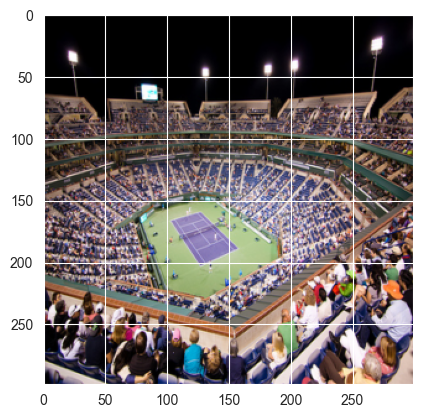

Reference captions: [
A group of children playing on the street , some on bicycles , and one on a scooter , and one in a blue shirt walking 
A group of four children cross the street , as an adult looks down the street 
Children playing with their bicycles and scooters 
Five children playing on a neighborhood street 
3 girls and one boy playing in the street 
]
Generated caption:   a man is riding a bike .


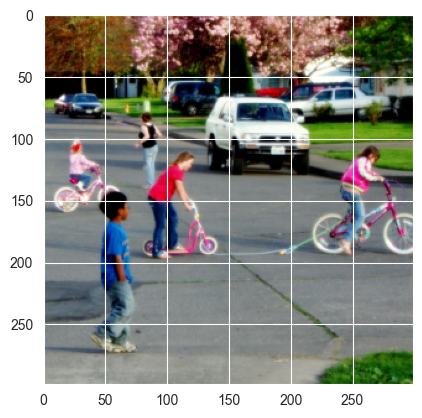

Reference captions: [
A patient in a hospital bed , with a cast on her left arm , and a hairnet on her head , sticks her tongue out at the camera 
The women in the blue surgical cap is sticking her tongue out and appears to be wearing a cast on her left arm 
A female patent at a hospital sticking out her tongue 
A woman in a hospital bed sticking out her tongue 
woman in the hospital sticking her tongue ou
]
Generated caption:   a woman in a white shirt is sitting in a of .


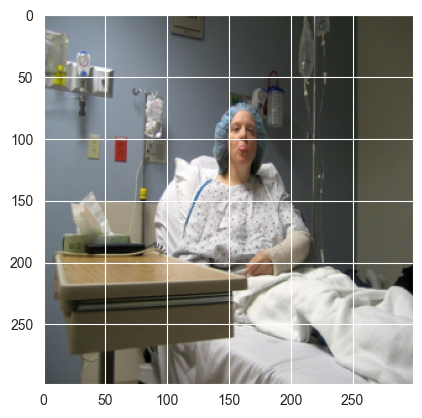

Reference captions: [
Dog on leash burrows into snow in rural area 
The large black dog is digging in the snow 
A black dog is digging in the snow 
A dog buries its head in the snow 
Dog with head in snow 
]
Generated caption:   a black and white dog jumping in the snow .


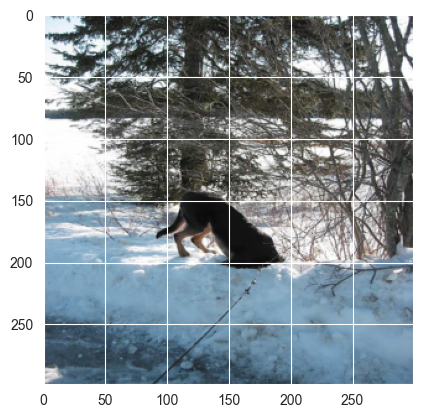

Reference captions: [
Female athlete for the bulls is holding what looks to be a hockey stick , with rocks and trees in the back 
A young blond-haired woman is wearing a Bull 's athletic uniform with the number nineteen on it 
A young blond woman in a blue jersey holds her stick waiting for the game to start 
A young athlete is on the field looking at something in the distance 
A blond woman on a playing field holds her polo stick at the ready 
]
Generated caption:   a girl in a white shirt is playing tennis .


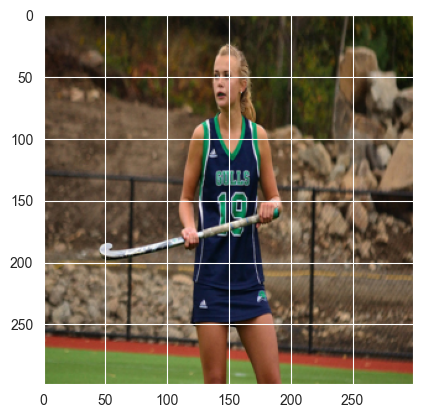

Reference captions: [
A group of construction workers are attempting to pull a cover onto a framework 
Six construction workers are pulling a roof up with ropes 
Construction workers are putting together a white canopy 
Construction workers putting up a building together 
Workers erect a pavilion for an event in the park 
]
Generated caption:   a man in a blue shirt and blue jeans walking down a street .


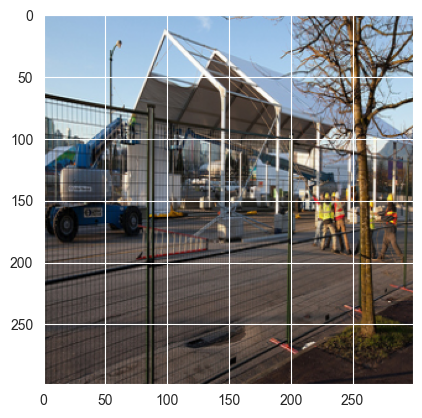

Reference captions: [
A woman wearing sunglasses and jeans runs and jumps down a sand dune with has lots of tire tracks and foot prints 
An adult surrounded with nothing but sand leaping into the air 
A young woman is jumping in front of a large sand dune 
A woman enjoying bouncing through the desert sands 
A woman jumping in a desert like area 
]
Generated caption:   a man in a red shirt and black pants is jumping on the air .


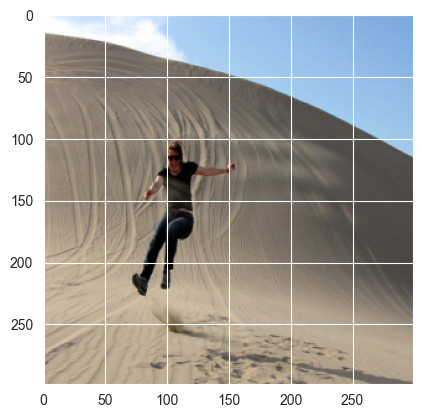

Reference captions: [
This Gentleman in a White Shirt , is really studying , at his Computer 
A man wearing glasses and a white shirt checks his email account 
A man sits in front of a wall map and looks at a computer screen 
A man sitting in front of his computer looking at his email 
man in blue shirt on street 
]
Generated caption:   a man in a white shirt is looking at a computer .


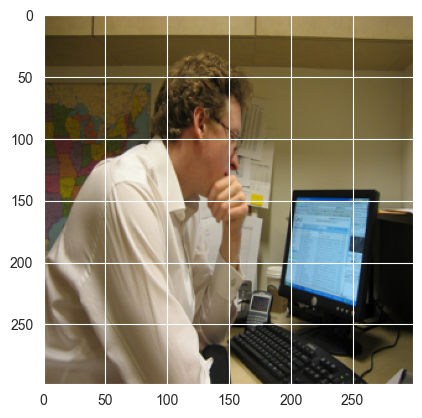

Reference captions: [
A group of people watch young men play the drums using makeshift buckets as instruments 
There are two street musicians playing percussion , while a crowd of people look on 
A crowd of people on the street gathering to watch several young men put on a show 
Bare chested Black men play drums on makeshift paint buckets to a pleased crowd 
A crowd of people are watch two guys play buckets 
]
Generated caption:   a group of people sitting on the ground .


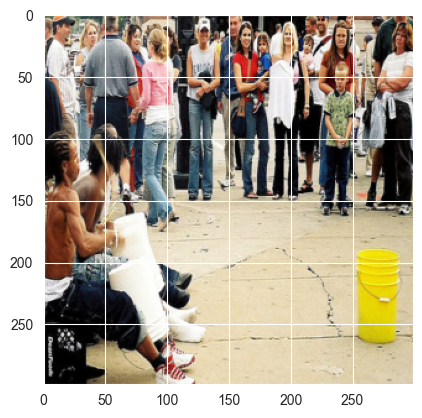

Reference captions: [
Two dogs , a golden one and a white one with black patches , are running towards something 
A black and white dog running in front of a brown dog in the grass 
A brown dog and black and white dog run along the green grass 
A brown dog and a white and black dog are running in grass 
Two dogs are running together through the grass 
]
Generated caption:   a brown and white dog is running in the grass .


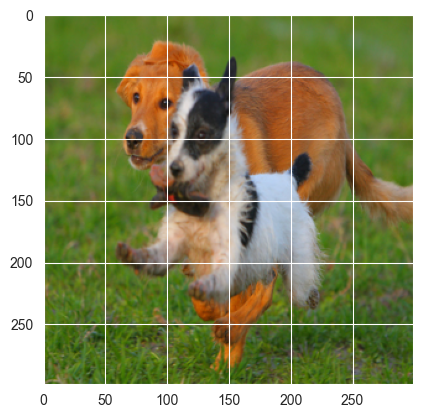

Reference captions: [
Two women in summer wear ride beach cruiser tricycles on the concrete near the beach 
Two women on low riding three-wheeled vehicles with baskets 
The two ladies are riding bicycles near the beach 
two women ride their three wheelers 
Two women riding tricycles 
]
Generated caption:   a group of people sitting on a bench .


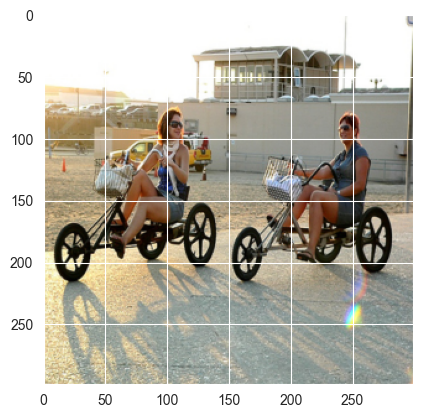

In [29]:

with torch.no_grad():
    # Отключаем вычисление градиентов, так как мы на этапе тестирования/оценки модели
    
    reference_captions = []  # Список для хранения эталонных (правильных) подписей
    generated_captions = []  # Список для хранения подписей, которые сгенерировала модель

    for imgs, captions, img_id in test_loader:
        # Поскольку batch size тестового загрузчика равен 1, берем только первое изображение
        img = imgs[0].to(device)  # Перемещаем изображение на вычислительное устройство

        # Генерируем подпись к изображению с помощью поиска луча (beam search)
        generated_caption = model.caption_image_beam_search(img, train_dataset.vocab)
        generated_caption = ' '.join(generated_caption)  # Собираем слова в строку

        # Добавляем эталонные подписи из словаря для данного изображения
        reference_captions.append(captions_dict.get_reference_captions(img_id[0]))
        # Добавляем сгенерированную подпись модели
        generated_captions.append(generated_caption)

        # Каждые 1500 итераций выводим пример с эталонными подписями и сгенерированной подписью
        if i % 1500 == 0:
            print("Reference captions: [")
            for r_cap in captions_dict.get_reference_captions(img_id[0]):
                print(r_cap, end='\n')
            print("]\nGenerated caption:", generated_caption)
            
            # Денормализация изображения (возврат к исходным значениям цветов)
            display_img = img.cpu()
            display_img = display_img * std[:, None, None] + mean[:, None, None]
            
            # Отображение изображения
            plt.imshow(display_img.permute(1, 2, 0))  # Меняем порядок осей для plt.imshow
            plt.show()  # Показываем изображение

        i += 1  # Увеличиваем счетчик обработанных изображений

In [30]:

# Вычисление BLEU-метрики для оценки качества сгенерированных подписей

smooth_fn = SmoothingFunction().method4  # Инициализация функции сглаживания для улучшения подсчёта BLEU
# Подготавливаем эталонные подписи: разбиваем каждую подпись на список слов для всех эталонов каждого изображения
references = [[ref.split() for ref in refs] for refs in reference_captions]
# Аналогично подготавливаем сгенерированные подписи: разбиваем каждую в сгенерированных на слова
candidates = [gen.split() for gen in generated_captions]
# Вычисляем BLEU-оценку с использованием сглаживающей функции
bleu = corpus_bleu(references, candidates, smoothing_function=smooth_fn)
# Выводим итоговое значение BLEU для оценки качества модели
print(f"BLEU Score: {bleu}")

BLEU Score: 0.5892747795032931


/Users/aleksandrkoval/PycharmProjects/ML/virt/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


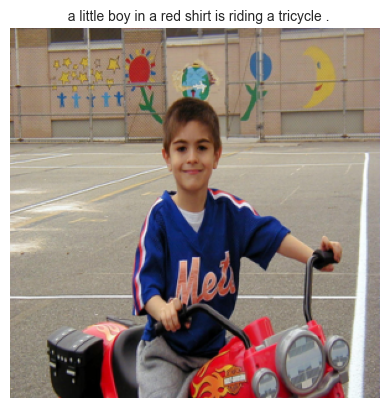

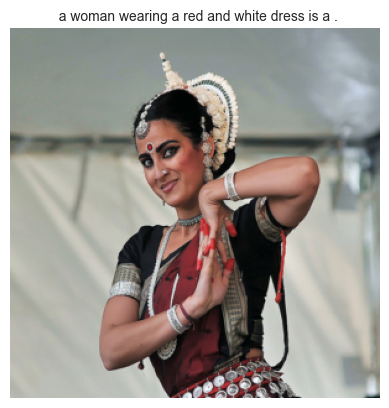

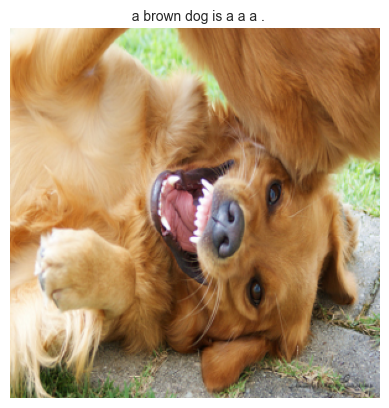

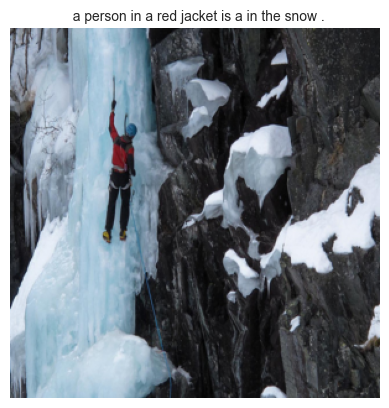

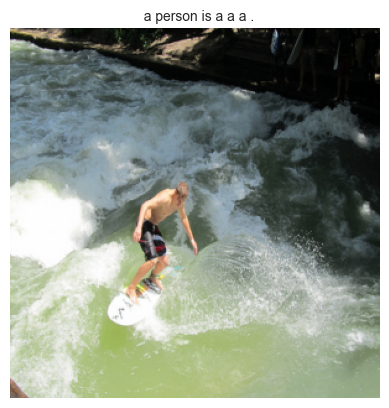

In [31]:
# Средние значения каналов RGB для нормализации/денормализации изображений
mean = torch.tensor([0.5, 0.5, 0.5])
# Стандартные отклонения каналов RGB для нормализации/денормализации
std = torch.tensor([0.5, 0.5, 0.5])

for i, (imgs, captions, img_id) in enumerate(test_loader):
    # Ограничиваем вывод первыми 5 изображениями
    if i < 5:
        # Берём первое изображение из батча (batch size в test_loader = 1)
        img = imgs[0].to(device)
        
        # Генерируем подпись к изображению с помощью beam search
        generated_caption = model.caption_image_beam_search(img, train_dataset.vocab)
        
        # Перемещаем изображение на CPU для отображения
        display_img = img.cpu()
        # Денормализация изображения: возвращаем значения пикселей к исходному диапазону
        display_img = display_img * std[:, None, None] + mean[:, None, None]
        
        # Отображаем изображение с помощью matplotlib (меняем оси с CxHxW на HxWxC)
        plt.imshow(display_img.permute(1, 2, 0))
        plt.axis('off')  # Скрываем оси
        # Устанавливаем заголовок с сгенерированной подписью, объединённой в строку
        plt.title(' '.join(generated_caption), fontsize=10)
        plt.show()
    else:
        break  # Завершаем цикл после 5 изображений